# NEU Surface Defect Database — Exploratory Data Analysis

Exploring `data/raw/` for the 6-class steel surface defect classification proof-of-concept.
We got the **NEU-DET** variant (`.jpg`, per-class subfolders, PASCAL VOC annotations),
not NEU-CLS — but since the class name is encoded in the filename, we can use its images
directly for classification (annotations are ignored here).

All figures produced in this notebook are saved to `reports/figures/`.


In [1]:
import re
from itertools import combinations
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
RNG_SEED = 42
np.random.seed(RNG_SEED)
rng = np.random.default_rng(RNG_SEED)


def find_project_root(marker="CLAUDE.md"):
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root (looking for {marker})")


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root:    {DATA_ROOT}")
print(f"Figures dir:  {FIG_DIR}")


Project root: C:\Users\user\OneDrive\Desktop\AI-Powered Pipeline Defect Detection System
Data root:    C:\Users\user\OneDrive\Desktop\AI-Powered Pipeline Defect Detection System\data\raw
Figures dir:  C:\Users\user\OneDrive\Desktop\AI-Powered Pipeline Defect Detection System\reports\figures


## 1. Load image paths and parse labels from filenames

Labels come from the filename prefix (e.g. `crazing_1.jpg`, or NEU-CLS-style
short prefixes like `Cr_1.bmp`), not from folder structure — this works
regardless of which dataset variant we ended up with.


In [2]:
CLASSES = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]
CLS_PREFIX_MAP = {
    "cr": "crazing",
    "in": "inclusion",
    "pa": "patches",
    "ps": "pitted_surface",
    "rs": "rolled-in_scale",
    "sc": "scratches",
}


def classify_filename(stem: str):
    lower = stem.lower()
    for cls in CLASSES:
        if lower.startswith(f"{cls}_"):
            return cls
    return CLS_PREFIX_MAP.get(stem.split("_")[0].lower())


image_paths = sorted(
    p for p in DATA_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in (".bmp", ".jpg", ".jpeg")
)
labels = [classify_filename(p.stem) for p in image_paths]

df = pd.DataFrame({"path": image_paths, "label": labels})
n_unlabeled = df["label"].isna().sum()
df = df.dropna(subset=["label"]).reset_index(drop=True)

print(f"Total image files found: {len(image_paths)}")
print(f"Unlabeled (skipped):     {n_unlabeled}")
print(f"Labeled images used:     {len(df)}")
df["label"].value_counts().reindex(CLASSES)


Total image files found: 1800
Unlabeled (skipped):     0
Labeled images used:     1800


label
crazing            300
inclusion          300
patches            300
pitted_surface     300
rolled-in_scale    300
scratches          300
Name: count, dtype: int64

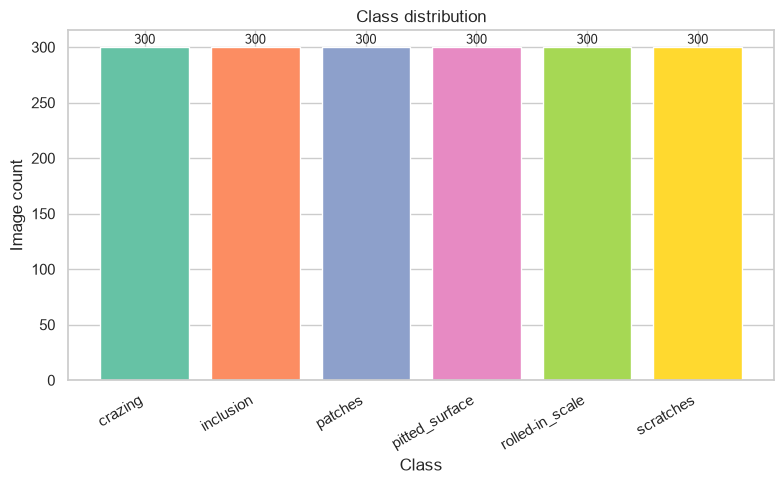

In [3]:
counts = df["label"].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(counts.index, counts.values, color=sns.color_palette("Set2", len(CLASSES)))
ax.set_title("Class distribution")
ax.set_ylabel("Image count")
ax.set_xlabel("Class")
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150)
plt.show()


**Commentary:** the dataset is perfectly balanced — 300 images per class, 1800 total.
No class-imbalance handling (weighted loss, resampling) will be needed for this dataset.


## 2. Sample grid — 5 random images per class

6 rows (one per class) x 5 columns (random samples), labeled.


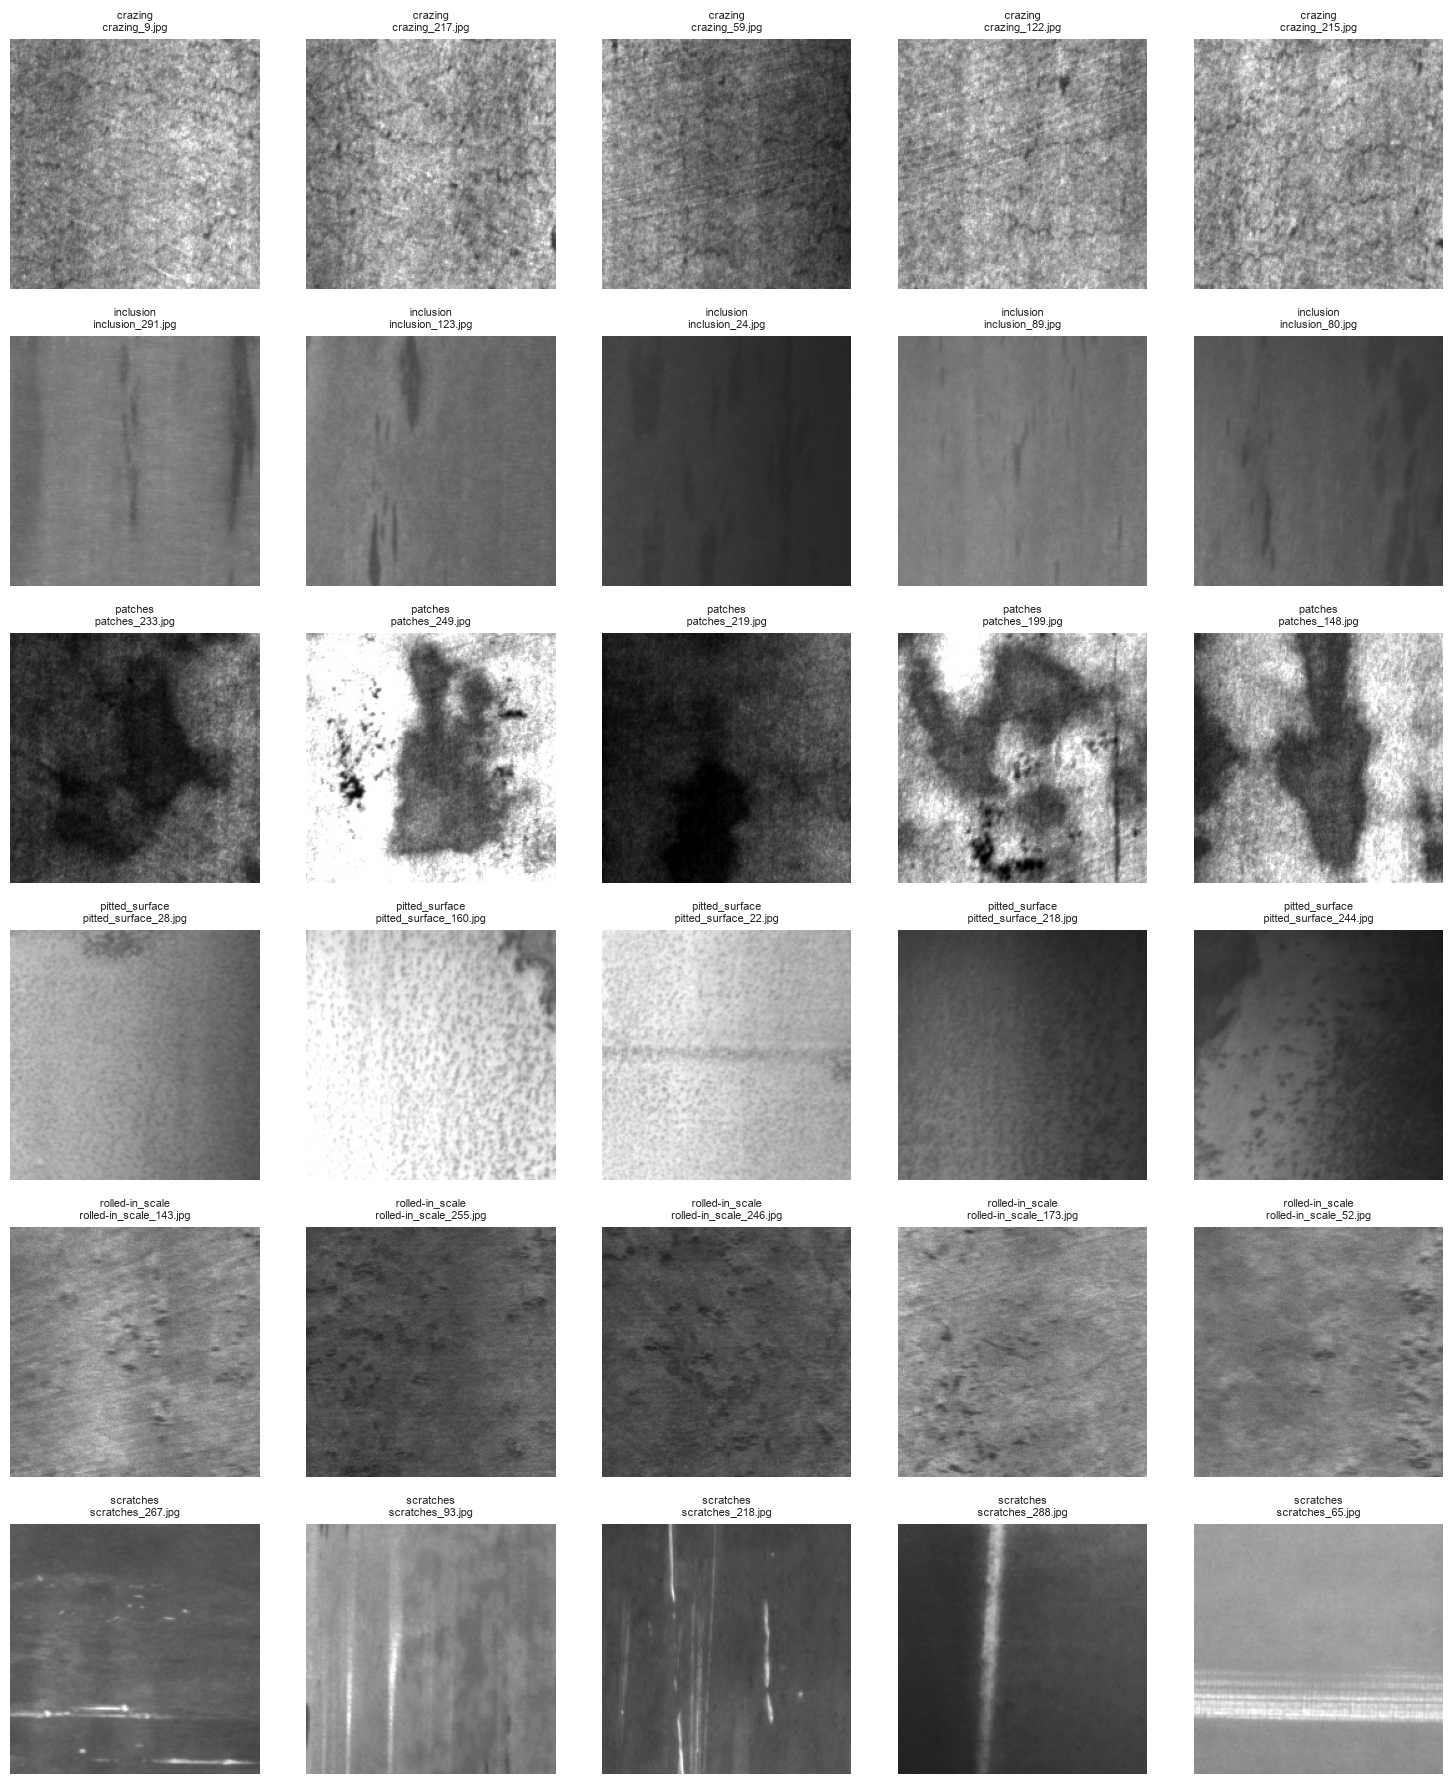

In [4]:
fig, axes = plt.subplots(6, 5, figsize=(15, 18))
for row, cls in enumerate(CLASSES):
    cls_paths = df.loc[df["label"] == cls, "path"].tolist()
    sample_paths = rng.choice(np.array(cls_paths, dtype=object), size=5, replace=False)
    for col, path in enumerate(sample_paths):
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(f"{cls}\n{Path(path).name}", fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "sample_grid.png", dpi=150)
plt.show()


## 3. Pixel intensity histograms per class (overlaid)

First, load every image once as grayscale and cache it — this array is reused
for the histograms, the per-class mean images (section 4), and the summary
statistics below, instead of re-reading from disk each time.


In [5]:
class_pixel_arrays = {}
for cls in CLASSES:
    cls_paths = df.loc[df["label"] == cls, "path"].tolist()
    imgs = np.stack([cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) for p in cls_paths])
    class_pixel_arrays[cls] = imgs
    print(f"{cls:>16}: loaded {imgs.shape[0]} images, shape {imgs.shape[1:]}")


         crazing: loaded 300 images, shape (200, 200)


       inclusion: loaded 300 images, shape (200, 200)


         patches: loaded 300 images, shape (200, 200)


  pitted_surface: loaded 300 images, shape (200, 200)


 rolled-in_scale: loaded 300 images, shape (200, 200)


       scratches: loaded 300 images, shape (200, 200)


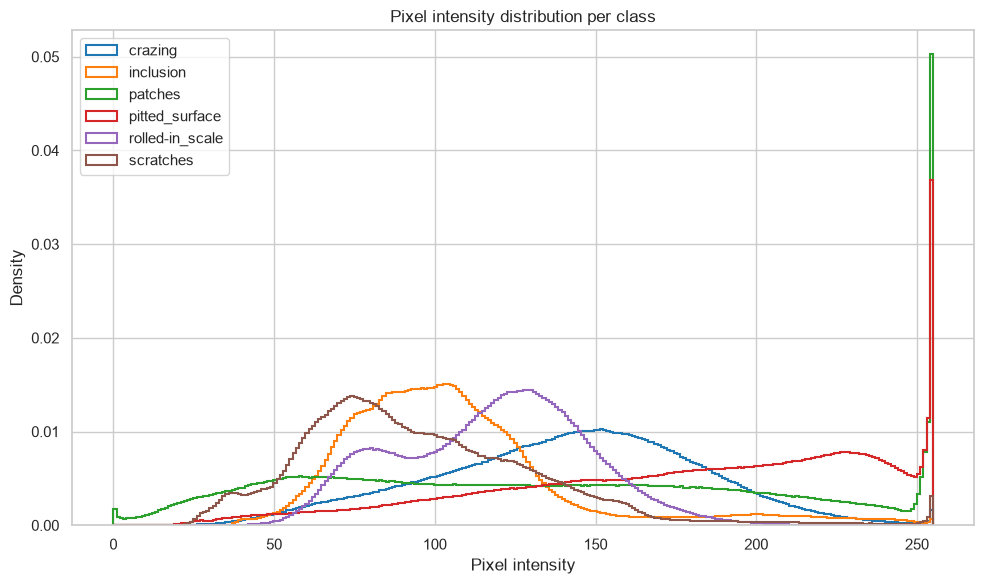

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("tab10", len(CLASSES))
for cls, color in zip(CLASSES, colors):
    pixels = class_pixel_arrays[cls].ravel()
    ax.hist(pixels, bins=256, range=(0, 255), histtype="step", density=True,
            label=cls, color=color, linewidth=1.5)
ax.set_xlabel("Pixel intensity")
ax.set_ylabel("Density")
ax.set_title("Pixel intensity distribution per class")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "pixel_histograms.png", dpi=150)
plt.show()


In [7]:
stats = []
for cls in CLASSES:
    pixels = class_pixel_arrays[cls].ravel()
    stats.append({"class": cls, "mean_intensity": pixels.mean(), "std_intensity": pixels.std()})
stats_df = pd.DataFrame(stats).set_index("class").reindex(CLASSES)
stats_df


,mean_intensity,std_intensity
class,,
crazing,141.107116,41.068698
inclusion,106.366375,36.647715
patches,132.510524,70.278974
pitted_surface,176.665727,56.544656
rolled-in_scale,117.912608,29.584327
scratches,95.145790,37.187413


**Commentary on separability by brightness alone:** see the printed mean/std
table above and the overlaid histogram. Where per-class means and spreads
overlap heavily, brightness alone will not separate those classes — texture
and edge structure (not intensity) is what the classifier will actually have
to key on for those. (Concrete pairs are quantified in section 6, using the
mean-image correlation below rather than eyeballing the plot.)


## 4. Mean image per class


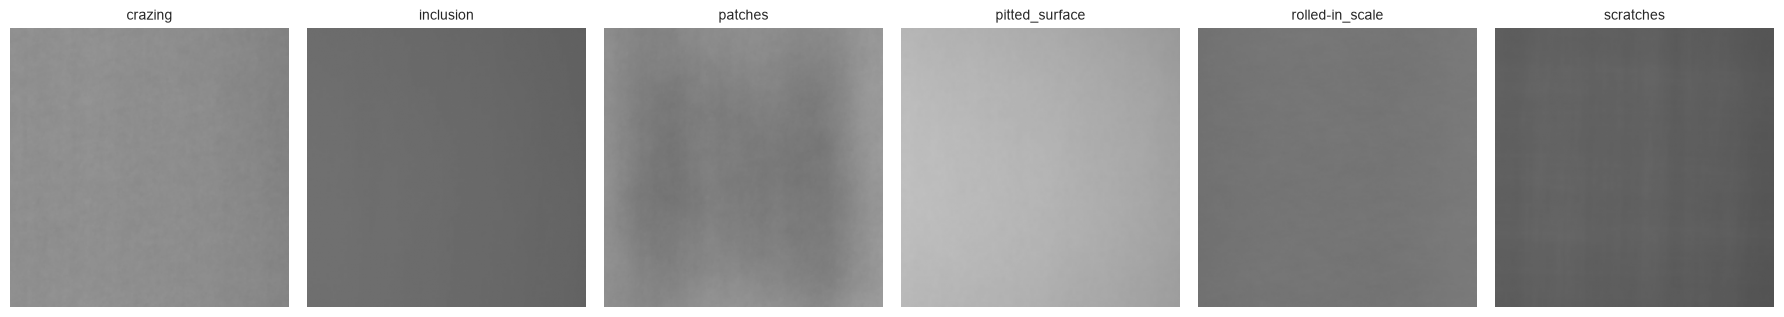

In [8]:
mean_images = {cls: class_pixel_arrays[cls].mean(axis=0) for cls in CLASSES}

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
for ax, cls in zip(axes, CLASSES):
    ax.imshow(mean_images[cls].astype(np.uint8), cmap="gray", vmin=0, vmax=255)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "mean_images.png", dpi=150)
plt.show()


In [9]:
print("Pairwise correlation between per-class mean images (higher = more similar / potentially confusable):")
mean_image_corr = []
for a, b in combinations(CLASSES, 2):
    corr = np.corrcoef(mean_images[a].ravel(), mean_images[b].ravel())[0, 1]
    mean_image_corr.append((a, b, corr))
mean_image_corr.sort(key=lambda x: -x[2])
for a, b, corr in mean_image_corr:
    print(f"  {a:>16} vs {b:<16}: {corr:.3f}")


Pairwise correlation between per-class mean images (higher = more similar / potentially confusable):
         inclusion vs pitted_surface  : 0.978
           crazing vs inclusion       : 0.833
    pitted_surface vs scratches       : 0.832
           crazing vs pitted_surface  : 0.828
           crazing vs scratches       : 0.800
         inclusion vs scratches       : 0.770
           patches vs rolled-in_scale : 0.365
         inclusion vs patches         : -0.403
           crazing vs patches         : -0.497
           patches vs pitted_surface  : -0.497
   rolled-in_scale vs scratches       : -0.617
           patches vs scratches       : -0.702
           crazing vs rolled-in_scale : -0.719
    pitted_surface vs rolled-in_scale : -0.788
         inclusion vs rolled-in_scale : -0.795


## 5. OpenCV preprocessing comparison

One representative sample per class, comparing: original | CLAHE (clipLimit=2.0,
tileGridSize=(8,8)) | histogram equalization | fastNlMeansDenoising | Canny(50,150).


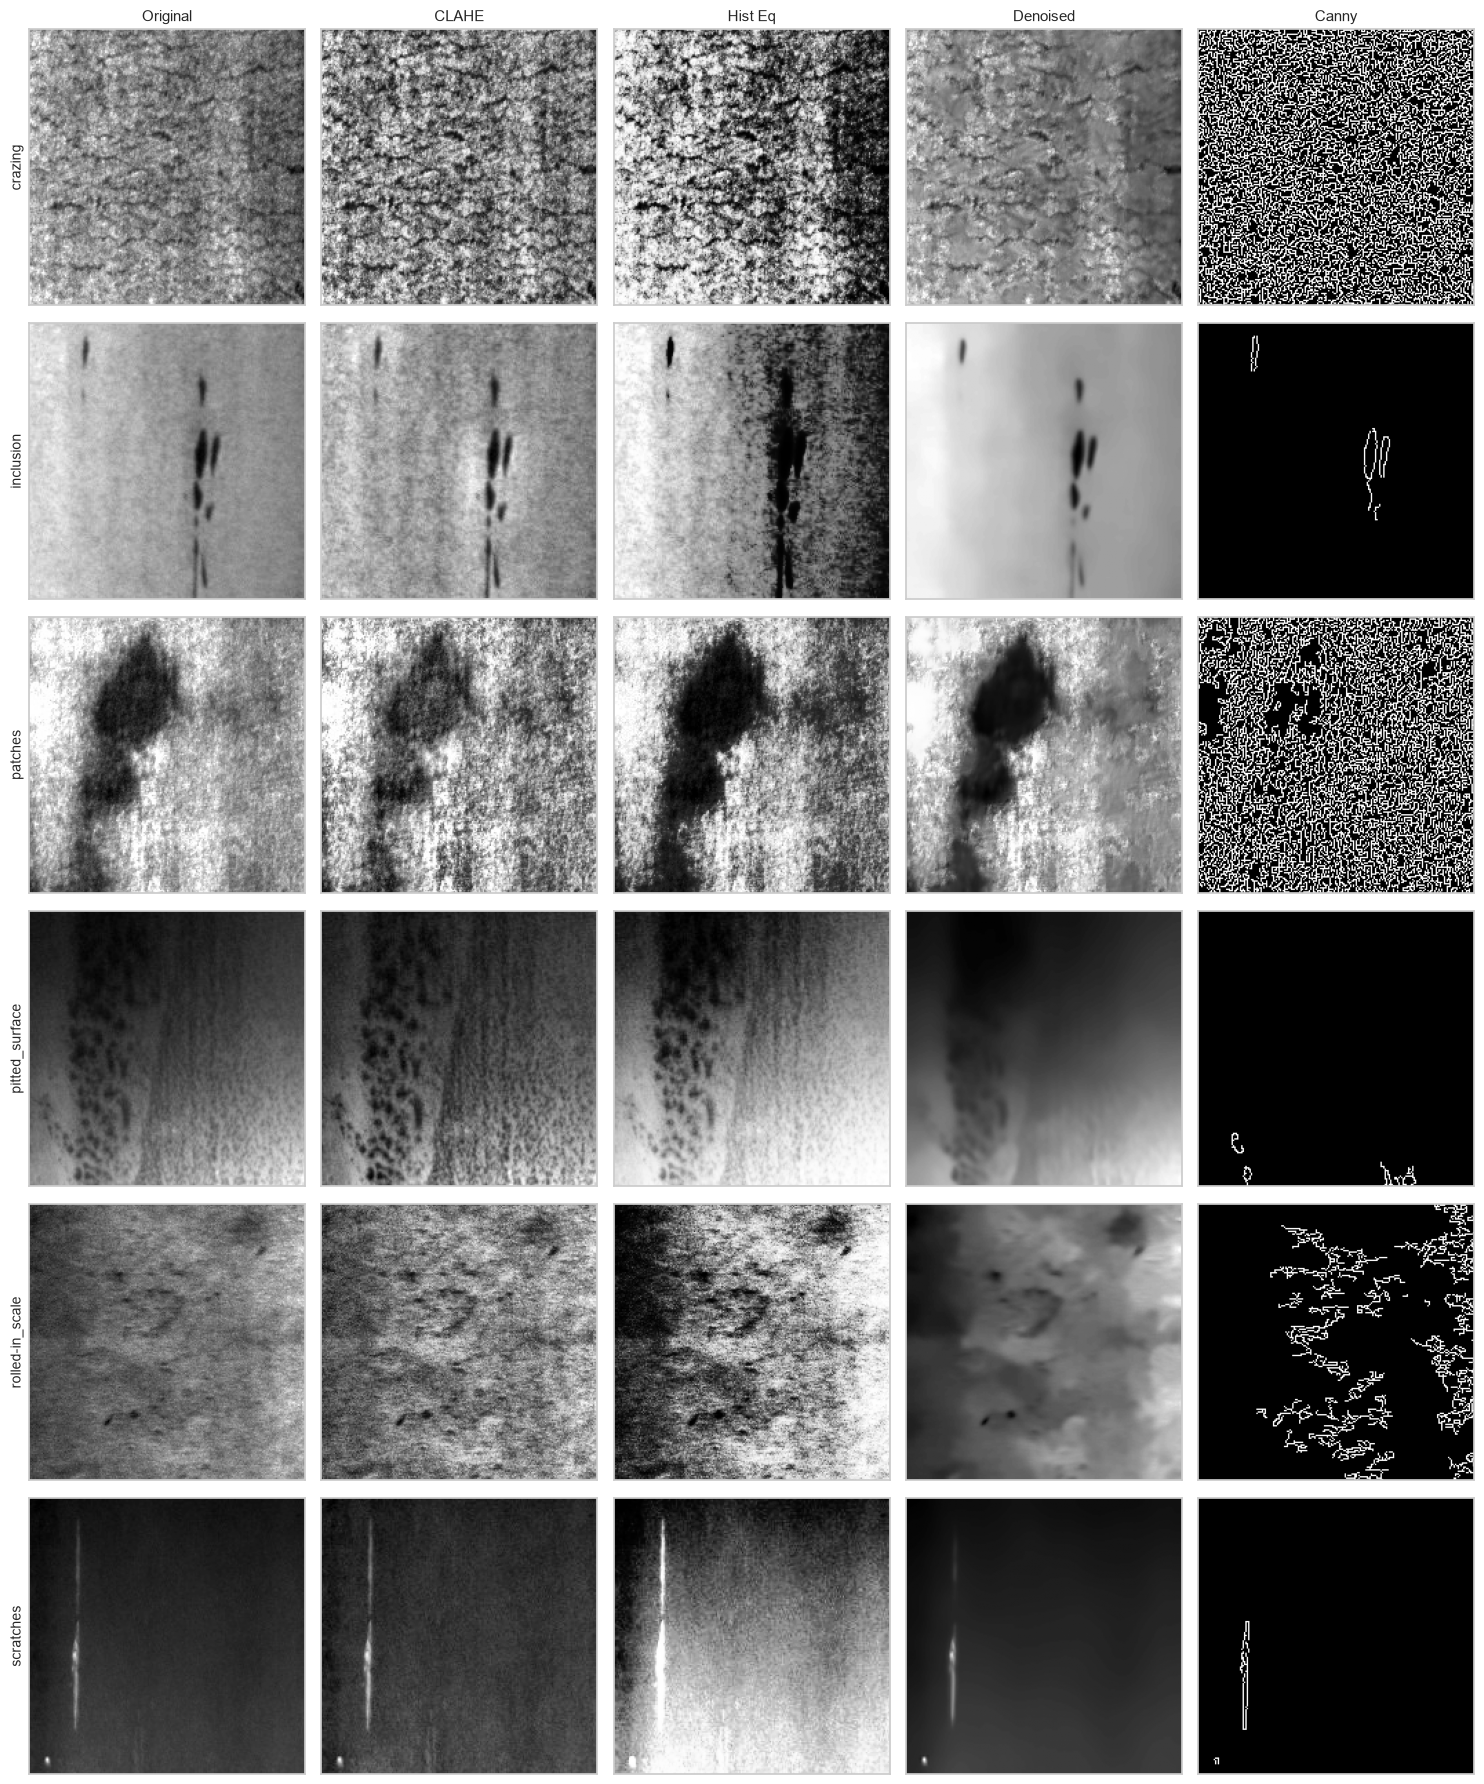

,orig_std,clahe_std,histeq_std,denoised_std,canny_edge_px
class,,,,,
crazing,28.498493,43.554297,73.563288,25.768853,15149
inclusion,14.053711,16.429683,72.740244,13.315356,236
patches,51.892511,56.452432,73.909824,50.984863,14421
pitted_surface,23.646034,28.004108,73.069707,23.049936,166
rolled-in_scale,18.697556,28.345463,73.501366,16.308577,3086
scratches,11.190173,12.910559,73.434398,10.784420,182


In [10]:
ops = ["Original", "CLAHE", "Hist Eq", "Denoised", "Canny"]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

sample_per_class = {cls: sorted(df.loc[df["label"] == cls, "path"].tolist())[0] for cls in CLASSES}

preproc_stats = []
fig, axes = plt.subplots(6, 5, figsize=(15, 18))
for row, cls in enumerate(CLASSES):
    img = cv2.imread(str(sample_per_class[cls]), cv2.IMREAD_GRAYSCALE)
    clahe_img = clahe.apply(img)
    hist_eq_img = cv2.equalizeHist(img)
    denoised_img = cv2.fastNlMeansDenoising(img, h=10)
    canny_img = cv2.Canny(img, 50, 150)
    variants = [img, clahe_img, hist_eq_img, denoised_img, canny_img]

    preproc_stats.append({
        "class": cls,
        "orig_std": img.std(),
        "clahe_std": clahe_img.std(),
        "histeq_std": hist_eq_img.std(),
        "denoised_std": denoised_img.std(),
        "canny_edge_px": int(np.count_nonzero(canny_img)),
    })

    for col, (op_name, out_img) in enumerate(zip(ops, variants)):
        ax = axes[row, col]
        ax.imshow(out_img, cmap="gray")
        if row == 0:
            ax.set_title(op_name, fontsize=11)
        if col == 0:
            ax.set_ylabel(cls, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR / "preprocessing_comparison.png", dpi=150)
plt.show()

preproc_df = pd.DataFrame(preproc_stats).set_index("class")
preproc_df


## 6. Conclusions

**Most visually confusable class pairs** (by correlation between per-class mean
images — section 4):

- **inclusion vs pitted_surface: r = 0.978** — the standout pair. But looking at
  the mean images directly (section 4 figure), this is *not* really about
  shared defect shape: averaging 300 images per class mostly washes out the
  actual defects and leaves a smooth left-right lighting gradient, and it's
  that shared imaging/lighting gradient driving the high correlation, not a
  shared defect appearance. This is a caveat on the metric more than a finding
  about the defects themselves.
- A looser cluster of **crazing, inclusion, pitted_surface, and scratches**
  (pairwise r 0.77-0.83) share the same broad gradient-dominated mean shape for
  the same reason.
- **patches** and **rolled-in_scale** stand apart (negative correlation with
  almost everything else) — their defects are large/textured enough to survive
  averaging and dominate the mean image instead of the lighting gradient.
- Looking at actual sample images (section 2 grid) rather than the averaged
  ones, the pair that looks genuinely confusable by eye is **crazing vs
  rolled-in_scale**: both are fine, diffuse, low-contrast textures across the
  whole image with no single dominant blob or line. **inclusion vs patches**
  are easier to tell apart in practice despite both being blob defects —
  patches blobs are larger, softer-edged, and often near-black, while
  inclusion blobs are smaller, streaky, and mid-gray.

**Separable by brightness alone?** No, not reliably. Per-class mean intensity
does differ (crazing 141, inclusion 106, patches 133, pitted_surface 177,
rolled-in_scale 118, scratches 95), but per-class std (30-70) is large enough
relative to those gaps that the overlaid histograms (section 3) show
substantial overlap in the 50-200 range for every class. Patches in particular
is nearly flat/uniform across the whole range (highest std of any class) with
its own saturation spike at 255, so it overlaps everyone. Texture and defect
shape, not raw intensity, will have to carry most of the classification signal.

**Which preprocessing makes defects more visible** (section 5 stats + visual
inspection of the comparison grid):

- **CLAHE** gives a mild, class-adaptive contrast boost (roughly 1.2x-1.6x the
  original std) without changing the character of the image much — safest
  default, but rarely a dramatic visibility win by itself.
- **Histogram equalization** is genuinely useful for the low-contrast,
  small-defect classes — it makes the scratches line and the pitted_surface
  pits much more visually prominent against their background. But for the
  already-noisy classes (crazing, patches) it mostly amplifies grain/speckle
  noise along with the defect, making them look harsher without adding real
  information. Its effect is class-dependent, not uniformly good or bad.
- **fastNlMeansDenoising** barely changes contrast (std nearly unchanged) but
  visibly cleans up background grain — for inclusion in particular this makes
  the defect blobs stand out clearly against a smoothed background. It over-
  smooths the fine speckle texture of rolled-in_scale, though, which loses
  some of that class's defining detail.
- **Canny(50,150)** behaves very differently depending on the defect's shape,
  and the raw edge-pixel counts (crazing 15,149 / patches 14,421 vs inclusion
  236 / scratches 182 / pitted_surface 166) are misleading on their own:
  - For **scratches** and **inclusion**, Canny is precise, not blind — it
    traces exactly the scratch line or inclusion blob outline against a clean,
    edge-free background. Low pixel count here means low noise, not low
    signal.
  - For **crazing** and **patches**, the high edge count is dominated by
    background grain/speckle noise, not just the defect boundary — the edge
    map is too busy to visually isolate the defect shape from the surrounding
    texture.
  - **rolled-in_scale** falls in between (3,086 edge px): Canny picks up a
    genuinely rich, scattered edge network that matches the speckled defect
    texture reasonably well.
  - **pitted_surface** is the weakest case: Canny only catches a few
    disconnected fragments of the many small pits, missing most of them.

**Practical takeaway:** no single preprocessing operation is best for every
class. CLAHE is the safe default; histogram equalization is worth it
specifically for scratches/pitted_surface; denoising helps most for inclusion;
and Canny is a strong feature for scratches/inclusion specifically (clean,
targeted edges) but not for crazing/patches (too noisy) or pitted_surface (too
sparse). A per-class or learned (rather than fixed, global) preprocessing
choice would likely outperform any single fixed pipeline. The inclusion vs
pitted_surface mean-image correlation is the one number in this notebook most
likely to mislead if taken at face value — it reflects shared lighting, not a
real defect confusion risk.
